# Analisis Spatial Scale — Visualisasi dan Proses Perhitungan

Notebook ini mendemonstrasikan efek **Spatial Scale** pada data skeleton BISINDO.

**Cara kerja `Scale`:**
- Setiap frame $t$ mendapatkan faktor skala acak $s_t \sim \mathcal{U}(\text{scale\_min}, \text{scale\_max})$
- Seluruh koordinat keypoint pada frame tersebut dikalikan: $\hat{x}_{t,k} = s_t \cdot x_{t,k}$
- Default range: $(0.8, 1.2)$ — sehingga tangan bisa menyusut hingga 80% atau membesar hingga 120%

**Yang ditampilkan:**
1. Tabel proses perhitungan per-keypoint untuk beberapa landmark penting
2. Visualisasi grid **1 baseline + 4 epoch** (setiap epoch = faktor skala acak berbeda)


In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)

plt.style.use('default')
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.serif'       : ['Times New Roman'],
    'font.size'        : 9,
    'axes.titlesize'   : 9,
    'axes.titleweight' : 'bold',
    'figure.dpi'       : 150,
    'savefig.dpi'      : 600,
    'savefig.bbox'     : 'tight',
})

SCALE_RANGE  = (0.8, 1.2)
TARGET_FRAME = 35

# MediaPipe hand skeleton connections (local index 0–20)
HAND_CONNS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (5,9),(9,10),(10,11),(11,12),
    (9,13),(13,14),(14,15),(15,16),
    (13,17),(17,18),(18,19),(19,20),
    (0,17)
]

print(f'Scale range : {SCALE_RANGE}')
print(f'Target frame: {TARGET_FRAME}')

Scale range : (0.8, 1.2)
Target frame: 35


## Load Data

In [2]:
with open('../data/pickle/pose_bisindo.pkl', 'rb') as f:
    dataset = pickle.load(f)

SELECTED_ID = 'P1_S15_R1'
assert SELECTED_ID in dataset, f'{SELECTED_ID} tidak ditemukan. Sample key: {list(dataset.keys())[:5]}'

kp_data   = dataset[SELECTED_ID]['keypoints']  # (T, 86, 2)
assert TARGET_FRAME < len(kp_data), f'Frame {TARGET_FRAME} melebihi panjang video ({len(kp_data)})'

orig_full = kp_data[TARGET_FRAME].copy()   # (86, 2)
orig_rh   = orig_full[21:42].copy()        # tangan kanan, index lokal 0–20

# Hitung batas sumbu dari data aktual
def bbox_limits(pts, pad):
    v = pts[pts[:, 0] != 0]
    (xmin, ymin), (xmax, ymax) = v.min(0), v.max(0)
    return (xmin - pad, xmax + pad), (ymin - pad, ymax + pad)

# Batas raw space — diperlebar untuk menampung skala 1.2×
raw_xlim, raw_ylim = bbox_limits(orig_rh, pad=0.08)

print(f'Video  : {SELECTED_ID}  |  Shape: {kp_data.shape}')
print(f'Frame  : {TARGET_FRAME}')
print(f'RH x   : [{orig_rh[:,0].min():.4f}, {orig_rh[:,0].max():.4f}]')
print(f'RH y   : [{orig_rh[:,1].min():.4f}, {orig_rh[:,1].max():.4f}]')
print(f'Bbox x : {raw_xlim}')
print(f'Bbox y : {raw_ylim}')

Video  : P1_S15_R1  |  Shape: (115, 86, 2)
Frame  : 35
RH x   : [0.3117, 0.4681]
RH y   : [0.2705, 0.5817]
Bbox x : (np.float64(0.23165632605552672), np.float64(0.5480813252925872))
Bbox y : (np.float64(0.19045285701751707), np.float64(0.6616787481307983))


## Definisi Kelas Scale dan Fungsi Bantu

In [3]:
class Scale(object):
    """
    Scale skeleton sequences by applying random scaling factors.

    Args:
        scale_range (tuple): Range of scaling factors (min, max).
    """

    def __init__(self, scale_range=(0.8, 1.2)) -> None:
        self.scale_range = scale_range

    def __call__(self, skeleton, **kwargs):
        T = skeleton.shape[0]
        scales = np.random.uniform(*self.scale_range, size=T)
        scaled_skeleton = skeleton * scales[:, np.newaxis, np.newaxis]
        return scaled_skeleton


LANDMARK_NAMES = {
    0  : "Wrist",
    4  : "Thumb Tip",
    8  : "Index Tip",
    12 : "Middle Tip",
    20 : "Pinky Tip",
}


def apply_scale_single_frame(points, scale_factor, frame=None):
    """
    Terapkan scaling pada satu frame dan tampilkan tabel proses perhitungan.

    Parameters
    ----------
    points : np.ndarray, shape (21, 2)
        Koordinat keypoint tangan kanan (raw space).
    scale_factor : float
        Faktor skala yang digunakan (s_t).
    frame : int or None
        Nomor frame untuk label tabel.

    Returns
    -------
    np.ndarray, shape (21, 2)
        Koordinat setelah scaling.
    """
    result = points * scale_factor

    print("\n" + "=" * 110)
    print(f"Spatial Scale  |  Faktor skala s_t = {scale_factor:.4f}  |  Rumus: x_scaled = s_t × x_original")
    print("=" * 110)

    header = (
        f"{'Frame':<8}"
        f"{'Landmark':<16}"
        f"{'Koordinat Awal (x, y)':<28}"
        f"{'Faktor Skala s_t':<22}"
        f"{'Koordinat Setelah Scale (x, y)'}"
    )
    print(header)
    print("-" * 110)

    frame_text = "-" if frame is None else str(frame)

    for idx, name in LANDMARK_NAMES.items():
        print(
            f"{frame_text:<8}",
            f"{name:<16}",
            f"({points[idx,0]:.4f}; {points[idx,1]:.4f})".ljust(28),
            f"× {scale_factor:.4f}".ljust(22),
            f"({result[idx,0]:.4f}; {result[idx,1]:.4f})"
        )

    print("=" * 110)
    return result


def _draw_hand(ax, pts, color):
    """Gambar skeleton tangan dengan koneksi dan scatter point."""
    for p1, p2 in HAND_CONNS:
        if pts[p1, 0] == 0 or pts[p2, 0] == 0:
            continue
        ax.plot(
            [pts[p1, 0], pts[p2, 0]],
            [pts[p1, 1], pts[p2, 1]],
            color='#4169E1', alpha=0.45, lw=0.8, zorder=1
        )
    valid = pts[:, 0] != 0
    ax.scatter(
        pts[valid, 0], pts[valid, 1],
        c=color, s=18, edgecolors='black', linewidths=0.4, zorder=3
    )


def _style_ax(ax, title, xlim, ylim):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=8, pad=3)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('#F8F8F8')
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)


def plot_raw(ax, rh_21, title, color, xlim, ylim):
    _draw_hand(ax, rh_21, color)
    _style_ax(ax, title, xlim, ylim)


print('Kelas Scale dan fungsi bantu berhasil didefinisikan.')

Kelas Scale dan fungsi bantu berhasil didefinisikan.


## Proses Perhitungan Spatial Scale

Simulasi 4 epoch — setiap epoch mendapatkan faktor skala acak $s_t \sim \mathcal{U}(0.8, 1.2)$ yang berbeda-beda.  
Tabel di bawah menunjukkan transformasi koordinat untuk landmark-landmark kunci pada **Frame 35**.

In [4]:
# Sampling 4 faktor skala (simulasi 4 epoch berbeda)
np.random.seed(42)
epoch_scales = np.random.uniform(*SCALE_RANGE, size=4)

print(f"Faktor skala yang disampling untuk frame {TARGET_FRAME}:")
for i, s in enumerate(epoch_scales, 1):
    print(f"  Epoch {i}: s_t = {s:.4f}")

# Terapkan dan tampilkan tabel perhitungan per epoch
scaled_versions = []
for i, s in enumerate(epoch_scales, 1):
    print(f"\n{'━'*110}")
    print(f"EPOCH {i}")
    result = apply_scale_single_frame(orig_rh, scale_factor=s, frame=TARGET_FRAME)
    scaled_versions.append(result)

Faktor skala yang disampling untuk frame 35:
  Epoch 1: s_t = 0.9498
  Epoch 2: s_t = 1.1803
  Epoch 3: s_t = 1.0928
  Epoch 4: s_t = 1.0395

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EPOCH 1

Spatial Scale  |  Faktor skala s_t = 0.9498  |  Rumus: x_scaled = s_t × x_original
Frame   Landmark        Koordinat Awal (x, y)       Faktor Skala s_t      Koordinat Setelah Scale (x, y)
--------------------------------------------------------------------------------------------------------------
35       Wrist            (0.3724; 0.5817)             × 0.9498               (0.3537; 0.5525)
35       Thumb Tip        (0.4681; 0.4460)             × 0.9498               (0.4446; 0.4236)
35       Index Tip        (0.4324; 0.3024)             × 0.9498               (0.4107; 0.2872)
35       Middle Tip       (0.3946; 0.2705)             × 0.9498               (0.3748; 0.2569)
35       Pinky Tip        (0.3117; 0.3577)             × 0.

## Visualisasi: Baseline vs 4 Epoch Spatial Scale

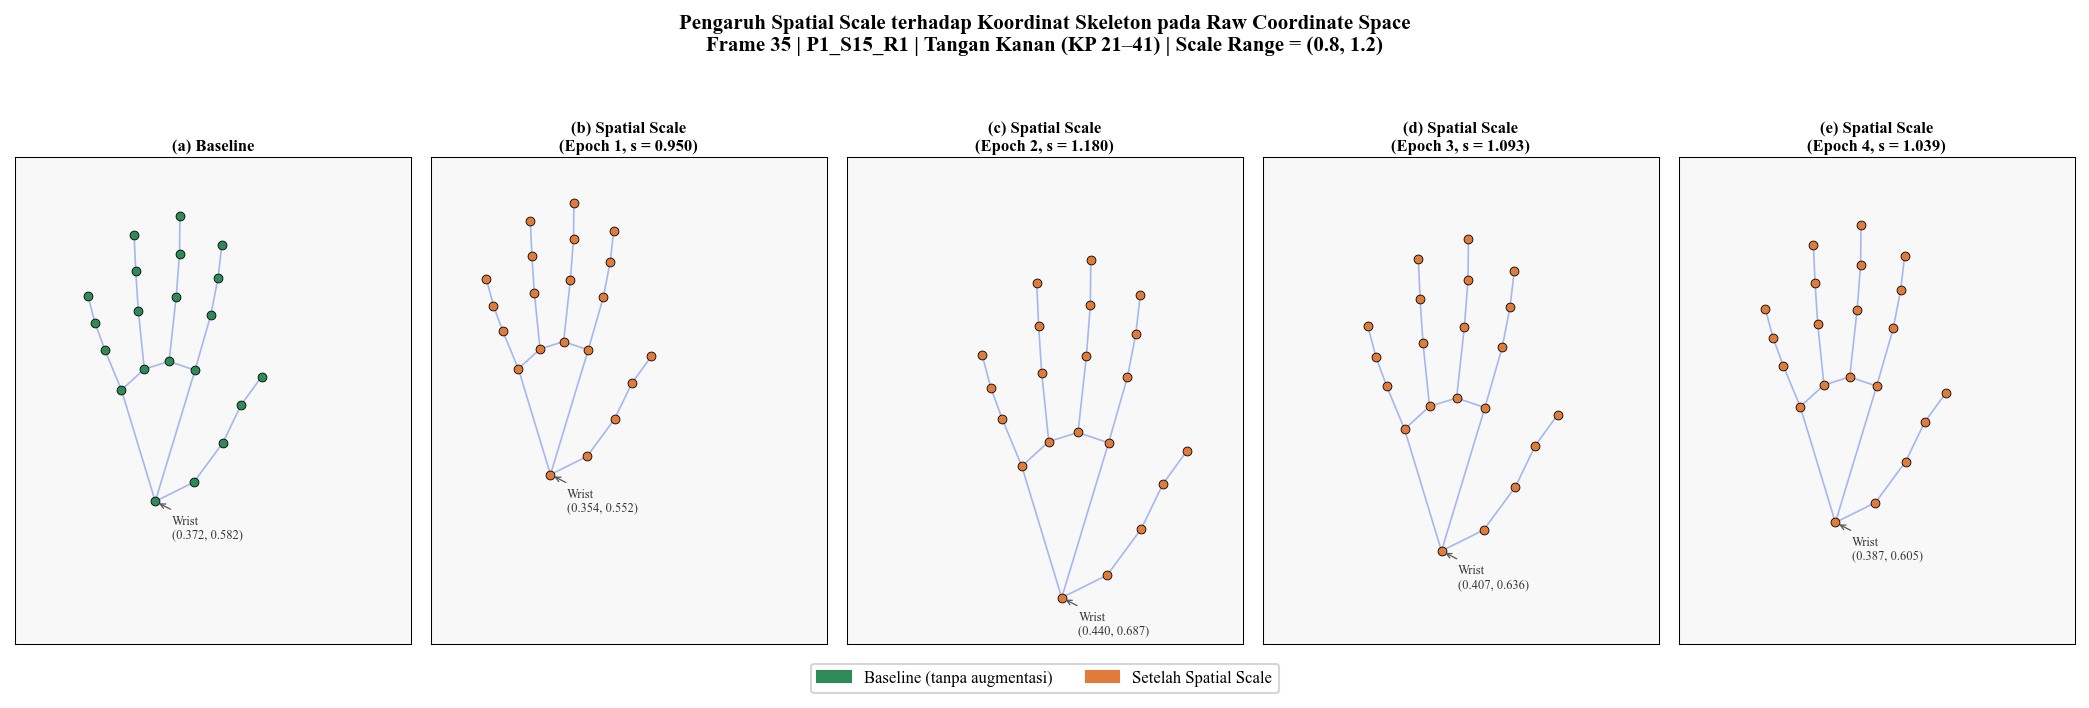

Saved: docs/perbandingan_baseline_vs_spatial_scale.png


In [18]:
COLOR_BASELINE = '#2E8B57'
COLOR_SCALE    = '#E07B39'

# ── Satu bbox bersama dari semua data ─────────────────────────
all_pts   = np.concatenate([orig_rh] + scaled_versions, axis=0)
valid_pts = all_pts[all_pts[:, 0] != 0]
pad       = 0.05
SHARED_XLIM = (valid_pts[:, 0].min() - pad, valid_pts[:, 0].max() + pad)
SHARED_YLIM = (valid_pts[:, 1].min() - pad, valid_pts[:, 1].max() + pad)

def plot_shared(ax, rh_21, title, color):
    _draw_hand(ax, rh_21, color)
    ax.set_xlim(*SHARED_XLIM)
    ax.set_ylim(*SHARED_YLIM)
    ax.invert_yaxis()
    # Tanpa set_aspect('equal') — supaya tidak ada yang terpotong
    ax.set_title(title, fontsize=8, pad=3)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('#F8F8F8')
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# Rasio aspek subplot disesuaikan dengan rentang koordinat
x_span = SHARED_XLIM[1] - SHARED_XLIM[0]
y_span = SHARED_YLIM[1] - SHARED_YLIM[0]
panel_w = 2.8
panel_h = panel_w * (y_span / x_span)   # proporsional ke data

fig, axes = plt.subplots(1, 5, figsize=(panel_w * 5, panel_h))

# ── Panel 0: Baseline ─────────────────────────────────────────
plot_shared(axes[0], orig_rh, title='(a) Baseline', color=COLOR_BASELINE)
wx, wy = orig_rh[0]
axes[0].annotate(
    f'Wrist\n({wx:.3f}, {wy:.3f})',
    xy=(wx, wy), xytext=(wx + 0.015, wy + 0.04),
    fontsize=6, color='#333333',
    arrowprops=dict(arrowstyle='->', color='#555', lw=0.6)
)

# ── Panel 1–4: Epoch 1–4 ──────────────────────────────────────
labels = ['(b)', '(c)', '(d)', '(e)']
for i, (scaled, s) in enumerate(zip(scaled_versions, epoch_scales)):
    ax = axes[i + 1]
    plot_shared(ax, scaled,
                title=f'{labels[i]} Spatial Scale\n(Epoch {i+1}, s = {s:.3f})',
                color=COLOR_SCALE)
    wx_s, wy_s = scaled[0]
    ax.annotate(
        f'Wrist\n({wx_s:.3f}, {wy_s:.3f})',
        xy=(wx_s, wy_s), xytext=(wx_s + 0.015, wy_s + 0.04),
        fontsize=6, color='#333333',
        arrowprops=dict(arrowstyle='->', color='#555', lw=0.6)
    )

# ── Legenda & Judul ───────────────────────────────────────────
fig.legend(
    handles=[
        mpatches.Patch(color=COLOR_BASELINE, label='Baseline (tanpa augmentasi)'),
        mpatches.Patch(color=COLOR_SCALE,    label='Setelah Spatial Scale'),
    ],
    loc='lower center', ncol=2, fontsize=8,
    frameon=True, bbox_to_anchor=(0.5, -0.06)
)
fig.suptitle(
    'Pengaruh Spatial Scale terhadap Koordinat Skeleton pada Raw Coordinate Space\n'
    f'Frame {TARGET_FRAME} | {SELECTED_ID} | Tangan Kanan (KP 21–41) '
    f'| Scale Range = {SCALE_RANGE}',
    fontsize=10, fontweight='bold', y=1.04
)

plt.tight_layout()
plt.savefig('docs/perbandingan_baseline_vs_spatial_scale.png', dpi=600, bbox_inches='tight')
plt.show()
print('Saved: docs/perbandingan_baseline_vs_spatial_scale.png')

## Visualisasi Distribusi Faktor Skala

Setiap frame dalam satu sekuens mendapatkan faktor skala independen $s_t \sim \mathcal{U}(0.8, 1.2)$.  
Plot di bawah mengilustrasikan distribusi faktor ini jika sekuens memiliki banyak frame.

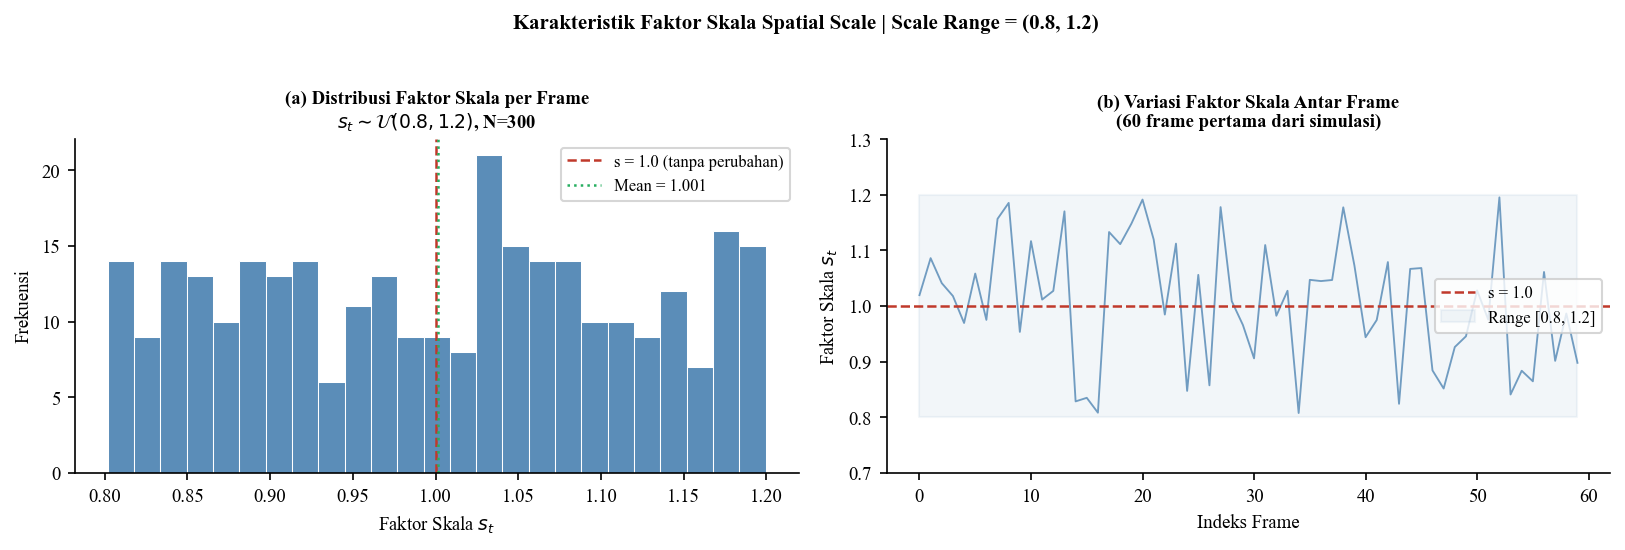

Saved: docs/distribusi_faktor_skala.png


In [12]:
T_SIM = 300  # simulasi 300 frame
np.random.seed(0)
sim_scales = np.random.uniform(*SCALE_RANGE, size=T_SIM)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# ── Kiri: distribusi histogram ────────────────────────────────
ax = axes[0]
ax.hist(sim_scales, bins=25, color='#5B8DB8', edgecolor='white', linewidth=0.5)
ax.axvline(1.0, color='#C0392B', lw=1.2, linestyle='--', label='s = 1.0 (tanpa perubahan)')
ax.axvline(sim_scales.mean(), color='#27AE60', lw=1.2, linestyle=':', label=f'Mean = {sim_scales.mean():.3f}')
ax.set_xlabel('Faktor Skala $s_t$', fontsize=9)
ax.set_ylabel('Frekuensi', fontsize=9)
ax.set_title('(a) Distribusi Faktor Skala per Frame\n'
             f'$s_t \\sim \\mathcal{{U}}({SCALE_RANGE[0]}, {SCALE_RANGE[1]})$, N={T_SIM}',
             fontsize=9)
ax.legend(fontsize=8)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# ── Kanan: time-series faktor skala ──────────────────────────
ax2 = axes[1]
ax2.plot(sim_scales[:60], color='#5B8DB8', lw=0.9, alpha=0.85)
ax2.axhline(1.0, color='#C0392B', lw=1.2, linestyle='--', label='s = 1.0')
ax2.fill_between(range(60), SCALE_RANGE[0], SCALE_RANGE[1],
                 alpha=0.08, color='#5B8DB8', label='Range [0.8, 1.2]')
ax2.set_xlabel('Indeks Frame', fontsize=9)
ax2.set_ylabel('Faktor Skala $s_t$', fontsize=9)
ax2.set_title('(b) Variasi Faktor Skala Antar Frame\n(60 frame pertama dari simulasi)',
              fontsize=9)
ax2.legend(fontsize=8)
ax2.set_ylim(0.70, 1.30)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

fig.suptitle(
    f'Karakteristik Faktor Skala Spatial Scale | Scale Range = {SCALE_RANGE}',
    fontsize=10, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('docs/distribusi_faktor_skala.png', dpi=600, bbox_inches='tight')
plt.show()
print('Saved: docs/distribusi_faktor_skala.png')

## Ringkasan

| Aspek | Detail |
|---|---|
| **Rumus** | $\hat{x}_{t,k} = s_t \cdot x_{t,k}$ untuk setiap frame $t$ dan keypoint $k$ |
| **Distribusi skala** | $s_t \sim \mathcal{U}(0.8, 1.2)$ — seragam, per-frame independen |
| **Efek spasial** | Keseluruhan tangan membesar ($s>1$) atau mengecil ($s<1$) — struktur relatif antar-keypoint tetap terjaga |
| **Efek temporal** | Setiap frame memiliki $s_t$ berbeda → variasi skala antar frame dalam satu sekuens |
| **Motivasi** | Mensimulasikan perbedaan jarak penanda ke kamera dan variasi ukuran tangan antar signer |
